# SAR2Height Prediction Pipeline

This notebook provides a complete end-to-end pipeline for running SAR-to-height predictions using trained regression and diffusion models with ensemble prediction and uncertainty quantification.

## Pipeline Overview

The SAR2Height prediction pipeline follows these key steps:

1. **Setup**: Load dependencies and configure paths
2. **Data Loading**: Load preprocessed SAR2Height patches and statistics
3. **Model Loading**: Initialize trained regression and diffusion models
4. **Prediction Pipeline**: Run regression → diffusion ensemble → uncertainty analysis
5. **Metrics & Evaluation**: Calculate comprehensive evaluation metrics
6. **Visualization**: Generate publication-quality plots and analysis
7. **Results Export**: Save all results and visualizations

## Key Features

- **Ensemble Prediction**: Generate multiple diffusion samples for uncertainty quantification
- **Comprehensive Metrics**: Standard regression metrics, height-specific accuracy measures, spatial analysis
- **Advanced Visualization**: Input channels, prediction comparisons, ensemble analysis, statistical plots
- **Experiment Management**: Automated workflow execution with result organization and saving
- **Scientific Analysis**: Perfect for model comparison and uncertainty analysis in research papers

## Setup and Dependencies

### Install required packages if needed

In [1]:
import subprocess
import sys

def install_package(package):
    """Install a package using pip if not already installed."""
    try:
        __import__(package.split('==')[0])
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f"✓ {package} installed successfully")

# Install required packages for prediction pipeline
required_packages = [
    'seaborn>=0.13.0',
    'scikit-learn>=1.3.0',
    'scipy>=1.10.0',
    'h5netcdf>=1.6.0'
]

print("🔧 Installing required packages for prediction pipeline...")
for package in required_packages:
    try:
        install_package(package)
    except Exception as e:
        print(f"⚠️  Warning: Could not install {package}: {e}")

print("\n✅ Package installation complete!")

🔧 Installing required packages for prediction pipeline...
📦 Installing seaborn>=0.13.0...



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


✓ seaborn>=0.13.0 installed successfully
📦 Installing scikit-learn>=1.3.0...



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


✓ scikit-learn>=1.3.0 installed successfully
📦 Installing scipy>=1.10.0...



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


✓ scipy>=1.10.0 installed successfully
📦 Installing h5netcdf>=1.6.0...
✓ h5netcdf>=1.6.0 installed successfully

✅ Package installation complete!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


### Standard library imports

In [2]:
import os
import sys
from pathlib import Path
import logging
import warnings
from typing import Dict, List, Optional, Tuple, Any
import time
from datetime import datetime

# Scientific computing imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

# PyTorch imports
import torch
import torch.nn as nn

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✓ Standard imports loaded successfully")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🚀 Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

✓ Standard imports loaded successfully
🔥 PyTorch version: 2.7.1+cu126
🚀 Device available: CUDA


### Prediction Pipeline imports

In [3]:
# Add the prediction pipeline directory to Python path
pipeline_dir = Path('./5-sar2height/prediction_pipeline').resolve()
if str(pipeline_dir) not in sys.path:
    sys.path.insert(0, str(pipeline_dir))

# Import prediction pipeline modules
import_success = {}
import_errors = {}

prediction_modules = [
    ('data_manager', ['SAR2HeightDataManager']),
    ('regression_pipeline', ['SAR2HeightRegressionPipeline']), 
    ('diffusion_pipeline', ['SAR2HeightDiffusionPipeline']),
    ('ensemble_analyzer', ['EnsembleAnalyzer']),
    ('metrics_calculator', ['SAR2HeightMetrics']),
    ('visualizer', ['SAR2HeightVisualizer']),
    ('experiment_manager', ['ExperimentManager'])
]

for module_name, imports in prediction_modules:
    try:
        module = __import__(module_name)
        for import_name in imports:
            globals()[import_name] = getattr(module, import_name)
        import_success[module_name] = True
        print(f"✅ {module_name}: {', '.join(imports)}")
    except ImportError as e:
        import_errors[module_name] = str(e)
        import_success[module_name] = False
        print(f"❌ Failed to import {module_name}: {e}")

# Report import status
successful_imports = sum(import_success.values())
total_modules = len(import_success)

print(f"\n📦 Prediction Pipeline Import Status: {successful_imports}/{total_modules} modules loaded")

if successful_imports == total_modules:
    print("🎉 All prediction pipeline components loaded successfully!")
    print("🚀 Ready for SAR2Height prediction workflow!")
else:
    failed_modules = [name for name, success in import_success.items() if not success]
    print(f"⚠️  Failed modules: {', '.join(failed_modules)}")
    print("\n🔍 Import Error Details:")
    for module, error in import_errors.items():
        print(f"  • {module}: {error}")
    print("\n💡 Consider checking module dependencies and file locations")

✅ data_manager: SAR2HeightDataManager
✅ regression_pipeline: SAR2HeightRegressionPipeline
✅ diffusion_pipeline: SAR2HeightDiffusionPipeline
✅ ensemble_analyzer: EnsembleAnalyzer
✅ metrics_calculator: SAR2HeightMetrics
✅ visualizer: SAR2HeightVisualizer
✅ experiment_manager: ExperimentManager

📦 Prediction Pipeline Import Status: 7/7 modules loaded
🎉 All prediction pipeline components loaded successfully!
🚀 Ready for SAR2Height prediction workflow!


In [4]:
! ls /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/

UNet.0.44000.mdlus  UNet.0.51008.mdlus	   checkpoint.0.48000.pt
UNet.0.45008.mdlus  UNet.0.52000.mdlus	   checkpoint.0.49008.pt
UNet.0.46000.mdlus  UNet.0.53008.mdlus	   checkpoint.0.50000.pt
UNet.0.47008.mdlus  checkpoint.0.44000.pt  checkpoint.0.51008.pt
UNet.0.48000.mdlus  checkpoint.0.45008.pt  checkpoint.0.52000.pt
UNet.0.49008.mdlus  checkpoint.0.46000.pt  checkpoint.0.53008.pt
UNet.0.50000.mdlus  checkpoint.0.47008.pt


In [5]:
! ls /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_diffusion/

EDMPrecondSuperResolution.0.10000.mdlus  checkpoint.0.10000.pt
EDMPrecondSuperResolution.0.1008.mdlus	 checkpoint.0.1008.pt
EDMPrecondSuperResolution.0.15008.mdlus  checkpoint.0.15008.pt
EDMPrecondSuperResolution.0.20000.mdlus  checkpoint.0.20000.pt
EDMPrecondSuperResolution.0.25008.mdlus  checkpoint.0.25008.pt
EDMPrecondSuperResolution.0.30000.mdlus  checkpoint.0.30000.pt
EDMPrecondSuperResolution.0.35008.mdlus  checkpoint.0.35008.pt
EDMPrecondSuperResolution.0.40000.mdlus  checkpoint.0.40000.pt
EDMPrecondSuperResolution.0.45008.mdlus  checkpoint.0.45008.pt
EDMPrecondSuperResolution.0.5008.mdlus	 checkpoint.0.5008.pt


## Configuration and Parameters

In [6]:
# =============================================================================
# CONFIGURATION PARAMETERS - SAR2Height Prediction Pipeline
# =============================================================================

# =============================================================================
# PATHS CONFIGURATION
# =============================================================================

# Base directories
BASE_DATA_DIR = Path("/app/data/sar2height/")
BASE_OUTPUT_DIR = Path("/app/outputs/sar2height/prediction_pipeline/")

# Data paths
DATA_FILE_PATH = BASE_DATA_DIR / "processed" / "preprocessed_patches" / "preprocessed_patches_ICEYE_X2_SLC_SLH_56495_20210517T180931_1054patches.nc"
STATS_DIR = str(BASE_DATA_DIR / "processed" / "preprocessed_patches")

# Model checkpoint paths
REGRESSION_CHECKPOINT = "/app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/UNet.0.53008.mdlus"
DIFFUSION_CHECKPOINT = "/app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_diffusion/EDMPrecondSuperResolution.0.45008.mdlus"

# Output directory for results
OUTPUT_DIR = str(BASE_OUTPUT_DIR)

# =============================================================================
# EXPERIMENT CONFIGURATION
# =============================================================================

# Experiment identification
EXPERIMENT_NAME = f"sar2height_prediction_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

# Data sample selection
SAMPLE_IDX = 0  # Which sample from the dataset to analyze

# Input variables to use (must match training configuration)
SELECTED_VARIABLES = [
    'intensity_db',
    'intensity_percentile_rescaled'
]

# =============================================================================
# MODEL CONFIGURATION
# =============================================================================

# Model architecture configuration (must match training)
REGRESSION_CONFIG = {
                "N_grid_channels": 4,
                "gridtype": "sinusoidal", 
                "embedding_type": "zero",
                "model_channels": 128,
                "channel_mult": [1, 2, 2, 2, 2],
                "attn_resolutions": [28],
                "model_type": "SongUNetPosEmbd",
            }

DIFFUSION_CONFIG = {
                    # Model architecture from diffusion_normal.yaml (EXACT MATCH)
                    "gridtype": "sinusoidal",
                    "N_grid_channels": 4,
                    "embedding_type": "zero",  # Changed from "positional" to "zero" like debug
                    "model_channels": 128,
                    "channel_mult": [1, 2, 2, 2, 2],
                    "attn_resolutions": [28],
                    "model_type": "SongUNetPosEmbd",
                    
                    # Model execution config (EXACT MATCH with training)
                    "use_fp16": False,
                    "checkpoint_level": 0,
                    "hr_mean_conditioning": True,  # This is the ONLY parameter passed to ResidualLoss
                }

# =============================================================================
# ENSEMBLE CONFIGURATION
# =============================================================================

# Ensemble prediction settings
ENSEMBLE_SIZE = 10  # Number of ensemble members to generate
ENSEMBLE_BASE_SEED = 42  # Base random seed for ensemble generation
DIFFUSION_STEPS = None  # Use default from model (or specify e.g., 50)

# =============================================================================
# ANALYSIS CONFIGURATION
# =============================================================================

# Visualization and output settings
SAVE_PLOTS = True  # Whether to save visualization plots
SAVE_DETAILED_RESULTS = True  # Whether to save detailed numerical results

# Figure quality settings
FIGURE_DPI = 150  # DPI for saved figures
FIGURE_FORMAT = 'png'  # Format for saved figures

# =============================================================================
# DEVICE CONFIGURATION
# =============================================================================

# Compute device selection
if torch.cuda.is_available():
    DEVICE = 'cuda'
    print(f"🚀 Using GPU: {torch.cuda.get_device_name()}")
else:
    DEVICE = 'cpu'
    print("💻 Using CPU")

# =============================================================================
# DIRECTORY CREATION
# =============================================================================

# Create necessary output directories
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# CONFIGURATION SUMMARY
# =============================================================================

print(f"\n🔧 SAR2Height Prediction Configuration Summary:")
print(f"  📁 Data file: {DATA_FILE_PATH.name}")
print(f"  📁 Stats directory: {STATS_DIR}")
print(f"  🤖 Regression checkpoint: {Path(REGRESSION_CHECKPOINT).name}")
print(f"  🌀 Diffusion checkpoint: {Path(DIFFUSION_CHECKPOINT).name}")
print(f"  📊 Output directory: {OUTPUT_DIR}")
print(f"  🎯 Experiment name: {EXPERIMENT_NAME}")
print(f"  🔢 Sample index: {SAMPLE_IDX}")
print(f"  📈 Input variables: {SELECTED_VARIABLES}")
print(f"  🎲 Ensemble size: {ENSEMBLE_SIZE}")
print(f"  🖥️  Device: {DEVICE.upper()}")
print(f"  💾 Save plots: {'ON' if SAVE_PLOTS else 'OFF'}")

# Validate critical paths
path_checks = [
    ('Data file', DATA_FILE_PATH),
    ('Stats directory', Path(STATS_DIR)),
    ('Regression checkpoint', Path(REGRESSION_CHECKPOINT)),
    ('Diffusion checkpoint', Path(DIFFUSION_CHECKPOINT))
]

print(f"\n🔍 Path Validation:")
all_paths_valid = True
for name, path in path_checks:
    if path.exists():
        print(f"  ✅ {name}: Found")
    else:
        print(f"  ❌ {name}: NOT FOUND - {path}")
        all_paths_valid = False

if all_paths_valid:
    print(f"\n🎉 All paths validated successfully! Ready to run prediction pipeline.")
else:
    print(f"\n⚠️  Some paths are missing. Please update the configuration above.")

🚀 Using GPU: Tesla V100-PCIE-32GB

🔧 SAR2Height Prediction Configuration Summary:
  📁 Data file: preprocessed_patches_ICEYE_X2_SLC_SLH_56495_20210517T180931_1054patches.nc
  📁 Stats directory: /app/data/sar2height/processed/preprocessed_patches
  🤖 Regression checkpoint: UNet.0.53008.mdlus
  🌀 Diffusion checkpoint: EDMPrecondSuperResolution.0.45008.mdlus
  📊 Output directory: /app/outputs/sar2height/prediction_pipeline
  🎯 Experiment name: sar2height_prediction_20260114_070801
  🔢 Sample index: 0
  📈 Input variables: ['intensity_db', 'intensity_percentile_rescaled']
  🎲 Ensemble size: 10
  🖥️  Device: CUDA
  💾 Save plots: ON

🔍 Path Validation:
  ✅ Data file: Found
  ✅ Stats directory: Found
  ✅ Regression checkpoint: Found
  ✅ Diffusion checkpoint: Found

🎉 All paths validated successfully! Ready to run prediction pipeline.


## Prediction Pipeline Execution

### Option 1: Complete Automated Workflow

🚀 Starting Complete SAR2Height Prediction Workflow
🚀 SAR2Height Experiment Manager initialized: sar2height_prediction_20260114_070801
📁 Results will be saved to: /app/outputs/sar2height/prediction_pipeline/sar2height_prediction_20260114_070801
📊 Predictions: /app/outputs/sar2height/prediction_pipeline/sar2height_prediction_20260114_070801/predictions
📈 Analysis: /app/outputs/sar2height/prediction_pipeline/sar2height_prediction_20260114_070801/analysis
🎨 Visualizations: /app/outputs/sar2height/prediction_pipeline/sar2height_prediction_20260114_070801/visualizations
🚀 STARTING COMPLETE SAR2HEIGHT PREDICTION EXPERIMENT
=== Setting up Data Manager ===
✓ SAR2Height statistics loaded
  - Input variables: ['intensity_db', 'intensity_percentile_rescaled']
  - Output variables: ['dsm_height']
✓ SAR2Height data loaded successfully
  - Sample index: 0
  - Input variables: ['intensity_db', 'intensity_percentile_rescaled']
  - Output variables: ['dsm_height']
  - Input shape: {'y_lr': 432, 'x_lr': 

WARNING - `DistributedManager` not initialized already. Initializing now, but this might lead to unexpected errors
INFO - Loaded model state dictionary /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/UNet.0.53008.mdlus to device cuda
INFO - Loaded checkpoint file /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/checkpoint.0.53008.pt to device cuda


✓ SAR2Height Regression model loaded successfully from epoch 53008
✓ Model set to evaluation mode
✓ Model moved to device: cuda
🌀 Setting up diffusion pipeline...
🎯 EXACT COPY: Initializing SAR2HeightDiffusionPipeline like train.py
✓ Deterministic inference configured (seed: 42)
🔧 Creating SAR2Height diffusion model EXACTLY like train.py...
✓ SAR2Height Model created: total_in_channels=7
   Dataset channels: 2
   HR mean conditioning: True
   Grid channels: 4
   Output channels: 1


INFO - Loaded model state dictionary /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_diffusion/EDMPrecondSuperResolution.0.45008.mdlus to device cuda
INFO - Loaded checkpoint file /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_diffusion/checkpoint.0.45008.pt to device cuda


✓ SAR2Height Diffusion model loaded from epoch 45008
🔧 Creating diffusion loss function with regression network...
🔧 Creating ResidualLoss for SAR2Height EXACTLY like train.py...
   Loading SAR2Height regression network from: /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/UNet.0.53008.mdlus
✓ SAR2Height regression network loaded successfully
✓ SAR2Height ResidualLoss created with:
   hr_mean_conditioning: True
   P_mean: 0.0 (class default)
   P_std: 1.2 (class default)
   sigma_data: 0.5 (class default)
✓ Diffusion loss function created successfully
✓ Model pipelines setup completed successfully
=== Running SAR2Height Predictions ===
✓ Input tensor prepared: torch.Size([1, 2, 432, 432])
  - Variables: ['intensity_db', 'intensity_percentile_rescaled']
  - Normalization applied: True
📊 Input prepared: torch.Size([1, 2, 432, 432]), Variables: ['intensity_db', 'intensity_percentile_rescaled']
🎯 Ground truth shape: (432, 432)

🤖 Running regres

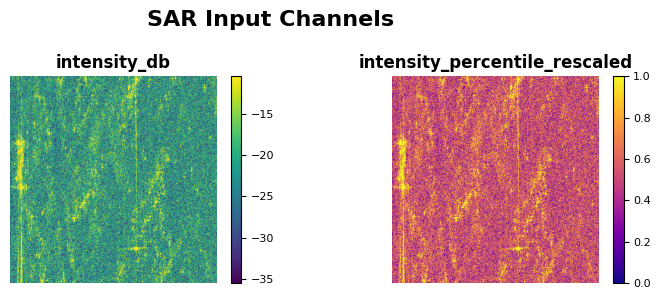

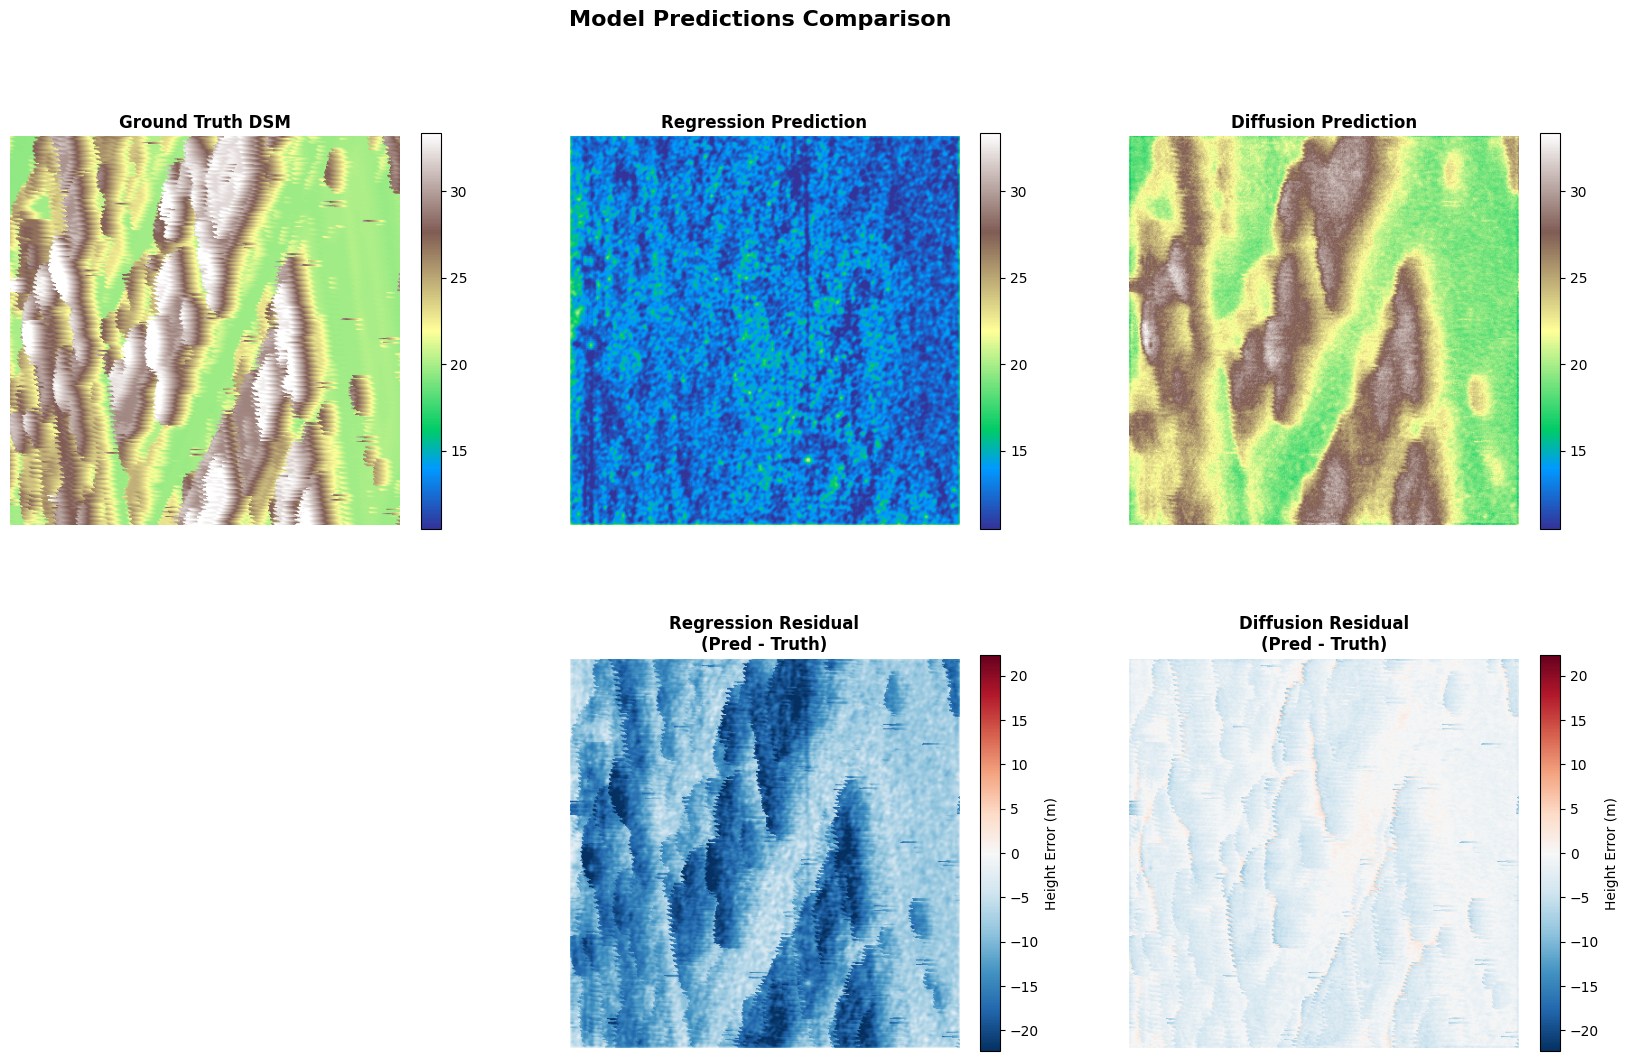

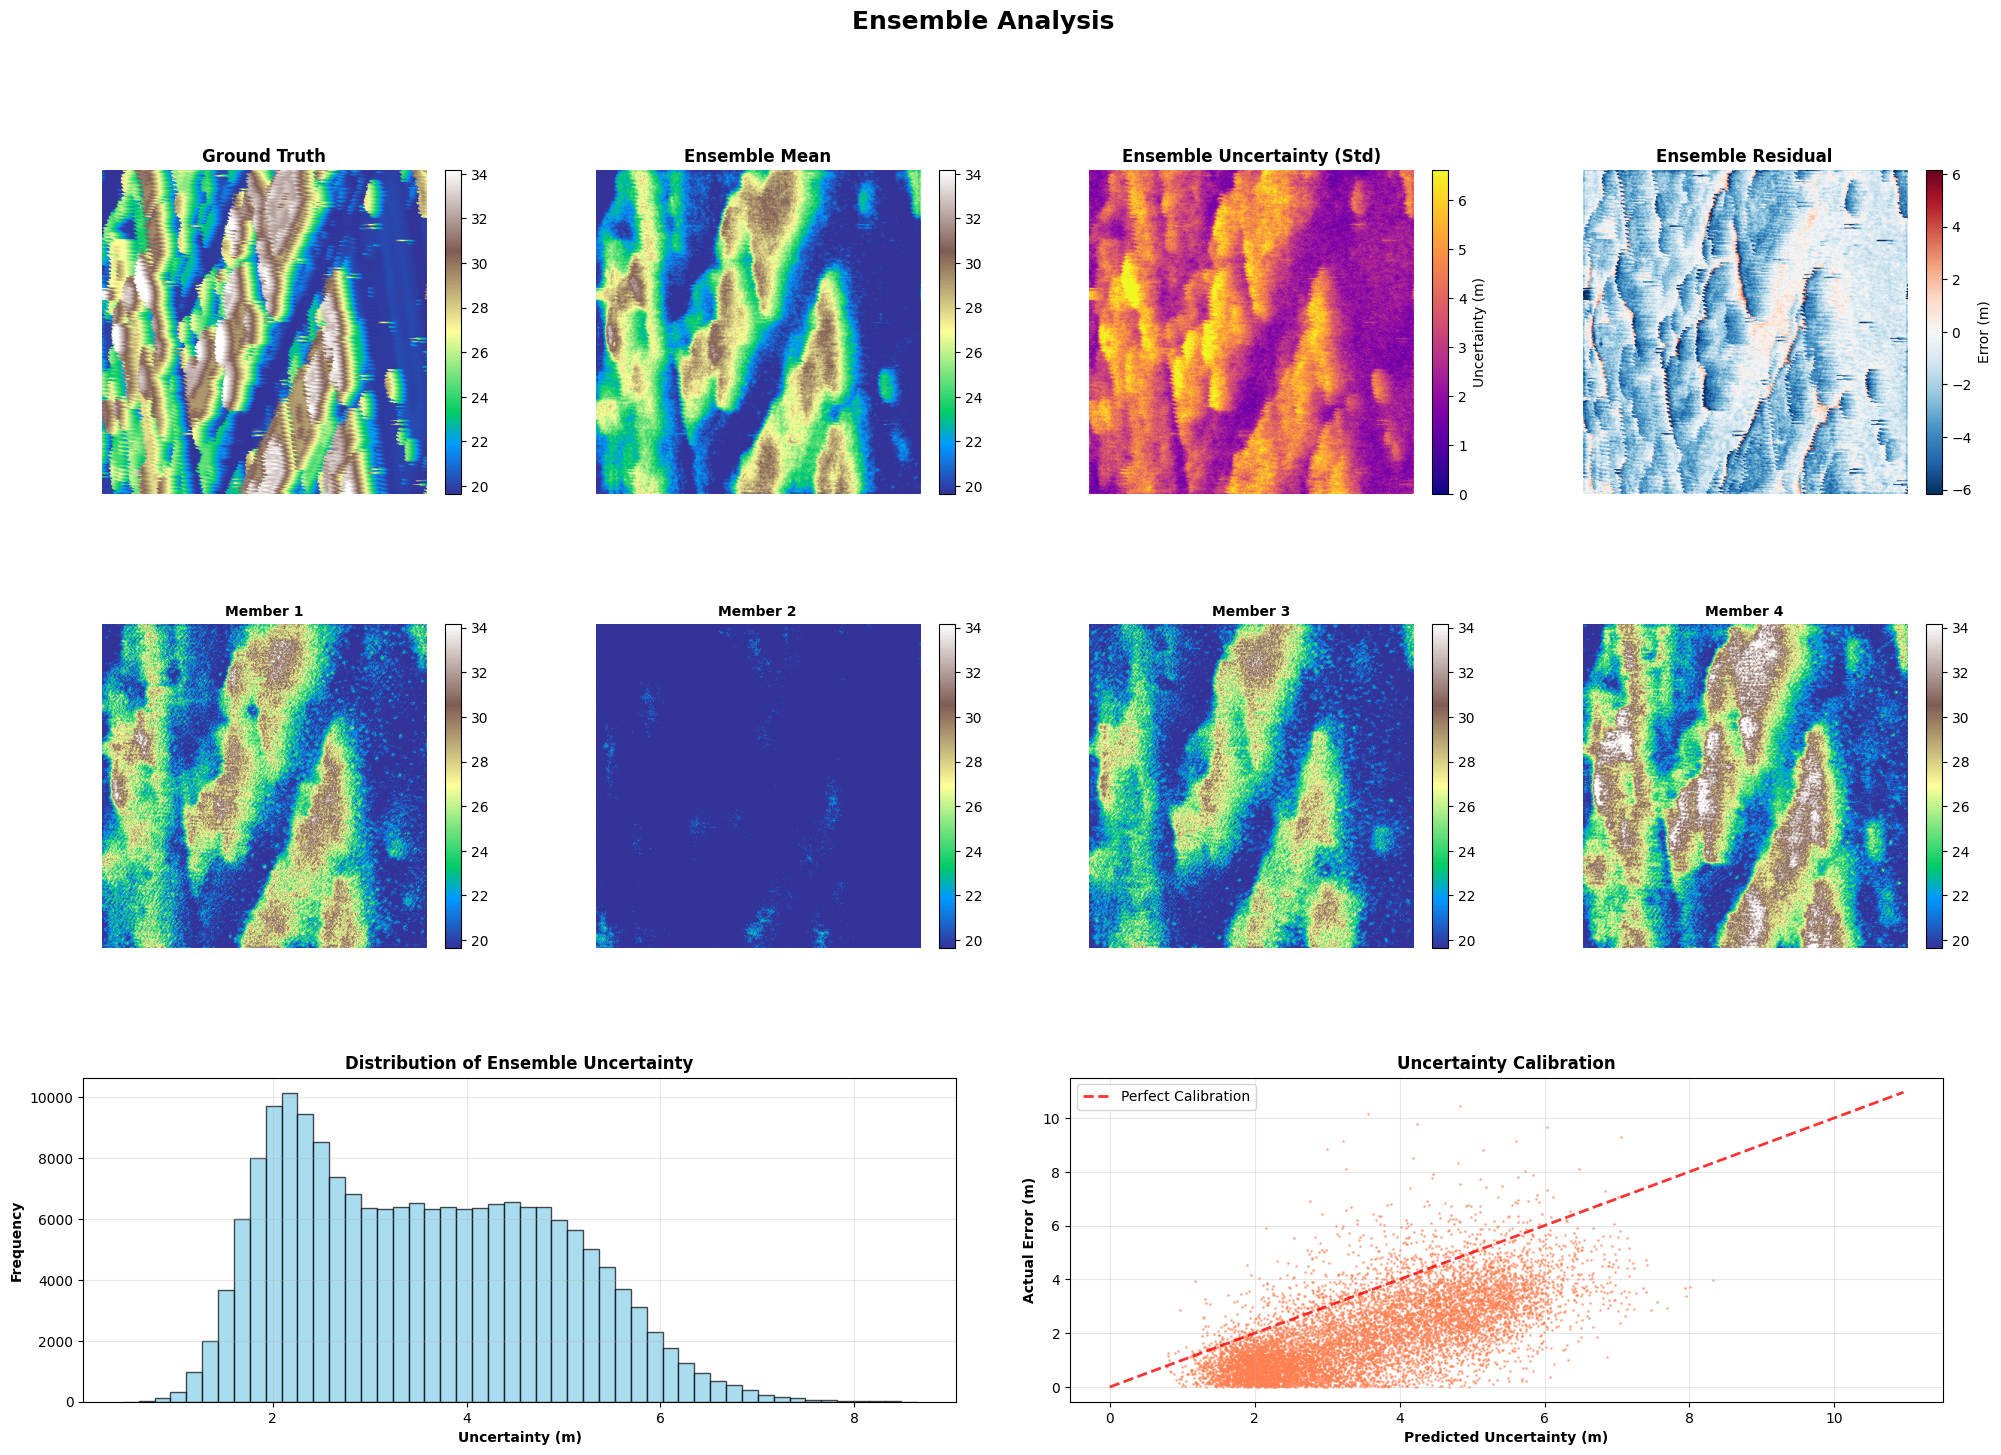

In [7]:
# =============================================================================
# COMPLETE AUTOMATED PREDICTION WORKFLOW
# =============================================================================

if successful_imports == total_modules and all_paths_valid:
    print("🚀 Starting Complete SAR2Height Prediction Workflow")
    print("=" * 80)
    
    # Create experiment manager
    experiment = ExperimentManager(
        experiment_name=EXPERIMENT_NAME,
        output_dir=OUTPUT_DIR
    )
    
    # Run complete experiment
    success = experiment.run_complete_experiment(
        data_file_path=str(DATA_FILE_PATH),
        stats_dir=STATS_DIR,
        regression_config=REGRESSION_CONFIG,
        diffusion_config=DIFFUSION_CONFIG,
        regression_checkpoint=REGRESSION_CHECKPOINT,
        diffusion_checkpoint=DIFFUSION_CHECKPOINT,
        sample_idx=SAMPLE_IDX,
        selected_variables=SELECTED_VARIABLES,
        ensemble_size=ENSEMBLE_SIZE,
        ensemble_base_seed=ENSEMBLE_BASE_SEED,
        diffusion_steps=DIFFUSION_STEPS,
        save_plots=SAVE_PLOTS
    )
    
    if success:
        print("\n" + "=" * 80)
        print("🎉 PREDICTION PIPELINE COMPLETED SUCCESSFULLY!")
        print("=" * 80)
        
        # Get and display results summary
        summary = experiment.get_results_summary()
        
        print(f"\n📊 Results Summary:")
        print(f"  🎯 Experiment: {summary['experiment_name']}")
        
        # Model performance
        if 'model_performance' in summary:
            perf = summary['model_performance']
            print(f"  📈 Model Performance (RMSE):")
            if perf.get('regression_rmse'):
                print(f"     • Regression: {perf['regression_rmse']:.3f} m")
            if perf.get('diffusion_rmse'):
                print(f"     • Diffusion: {perf['diffusion_rmse']:.3f} m")
            if perf.get('ensemble_rmse'):
                print(f"     • Ensemble: {perf['ensemble_rmse']:.3f} m")
        
        # Visualization paths
        if 'visualization_paths' in summary:
            viz_paths = summary['visualization_paths']
            print(f"  🎨 Visualizations Generated: {len(viz_paths)}")
            for viz_name, viz_path in viz_paths.items():
                print(f"     • {viz_name}: {Path(viz_path).name}")
        
        print(f"\n📁 Results Location: {experiment.experiment_dir}")
        print(f"💡 Check the output directory for detailed results and visualizations!")
        
        # Store results for manual analysis if needed
        completed_experiment = experiment
        
    else:
        print("\n❌ Prediction pipeline failed. Check the error messages above.")
        completed_experiment = None

else:
    print("❌ Cannot run automated workflow:")
    if successful_imports < total_modules:
        print(f"   • Missing imports: {total_modules - successful_imports} modules failed")
    if not all_paths_valid:
        print(f"   • Invalid paths: Check configuration above")
    print("\n💡 Fix the issues above or use the manual step-by-step workflow below.")
    completed_experiment = None

### Option 2: Manual Step-by-Step Workflow

#### Step 1: Data Management

In [8]:
# =============================================================================
# MANUAL STEP-BY-STEP WORKFLOW
# =============================================================================

# Only run this section if you want manual control or if automated workflow failed
RUN_MANUAL_WORKFLOW = True  # Set to True to enable manual workflow

if RUN_MANUAL_WORKFLOW and successful_imports == total_modules:
    print("🔧 Starting Manual Step-by-Step Workflow")
    print("=" * 60)
    
    # Step 1: Initialize Data Manager
    print("\n📊 Step 1: Data Management")
    print("-" * 40)
    
    try:
        # Initialize data manager
        data_manager = SAR2HeightDataManager(str(DATA_FILE_PATH), STATS_DIR)
        
        # Load statistics and data
        data_manager.load_statistics()
        input_data, output_data, metadata = data_manager.load_sample_data(SAMPLE_IDX)
        
        # Prepare input tensor
        input_tensor = data_manager.prepare_input_tensor(
            selected_variables=SELECTED_VARIABLES, 
            apply_normalization=True
        )
        
        # Get ground truth
        ground_truth = data_manager.get_ground_truth()
        
        print(f"✅ Data loaded successfully")
        print(f"   📊 Input shape: {input_tensor.shape}")
        print(f"   🎯 Ground truth shape: {ground_truth.shape}")
        print(f"   📈 Selected variables: {SELECTED_VARIABLES}")
        
        data_loaded = True
        
    except Exception as e:
        print(f"❌ Data loading failed: {e}")
        data_loaded = False

else:
    print("⏭️  Skipping manual workflow (RUN_MANUAL_WORKFLOW=False or imports failed)")
    print("💡 Set RUN_MANUAL_WORKFLOW=True above to enable manual step-by-step execution")
    data_loaded = False

🔧 Starting Manual Step-by-Step Workflow

📊 Step 1: Data Management
----------------------------------------
✓ SAR2Height statistics loaded
  - Input variables: ['intensity_db', 'intensity_percentile_rescaled']
  - Output variables: ['dsm_height']
✓ SAR2Height data loaded successfully
  - Sample index: 0
  - Input variables: ['intensity_db', 'intensity_percentile_rescaled']
  - Output variables: ['dsm_height']
  - Input shape: {'y_lr': 432, 'x_lr': 432}
  - Output shape: {'y_hr': 432, 'x_hr': 432}
✓ Input tensor prepared: torch.Size([1, 2, 432, 432])
  - Variables: ['intensity_db', 'intensity_percentile_rescaled']
  - Normalization applied: True
✅ Data loaded successfully
   📊 Input shape: torch.Size([1, 2, 432, 432])
   🎯 Ground truth shape: (432, 432)
   📈 Selected variables: ['intensity_db', 'intensity_percentile_rescaled']


#### Step 2: Model Loading

In [9]:
if RUN_MANUAL_WORKFLOW and data_loaded:
    print("\n🤖 Step 2: Model Loading")
    print("-" * 40)
    
    try:
        n_input_channels = len(SELECTED_VARIABLES)
        
        # Initialize and load regression model
        regression_pipeline = SAR2HeightRegressionPipeline(
            REGRESSION_CONFIG, REGRESSION_CHECKPOINT
        )
        regression_loaded = regression_pipeline.load_model(n_input_channels)
        
        # Initialize and load diffusion model
        diffusion_pipeline = SAR2HeightDiffusionPipeline(
            DIFFUSION_CONFIG, DIFFUSION_CHECKPOINT
        )
        diffusion_loaded = diffusion_pipeline.load_model(n_input_channels)
        
        if regression_loaded and diffusion_loaded:
            print(f"✅ Models loaded successfully")
            print(f"   🔢 Input channels: {n_input_channels}")
            print(f"   🤖 Regression model: Ready")
            print(f"   🌀 Diffusion model: Ready")
            models_loaded = True
        else:
            print(f"❌ Model loading failed")
            print(f"   🤖 Regression: {'✅' if regression_loaded else '❌'}")
            print(f"   🌀 Diffusion: {'✅' if diffusion_loaded else '❌'}")
            models_loaded = False
            
    except Exception as e:
        print(f"❌ Model loading failed: {e}")
        models_loaded = False

else:
    models_loaded = False


🤖 Step 2: Model Loading
----------------------------------------
=== Creating SAR2Height Regression Model ===
SAR2Height Regression model created with:
  - Input channels: 6 (2 SAR + 4 grid)
  - Output channels: 1 (DSM height)
  - Resolution: 432x432
  - Model channels: 128
  - Channel multipliers: [1, 2, 2, 2, 2]
=== Loading SAR2Height Regression Model ===
Loading from: /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/UNet.0.53008.mdlus


INFO - Loaded model state dictionary /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/UNet.0.53008.mdlus to device cuda
INFO - Loaded checkpoint file /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_regression/checkpoint.0.53008.pt to device cuda


✓ SAR2Height Regression model loaded successfully from epoch 53008
✓ Model set to evaluation mode
✓ Model moved to device: cuda
🎯 EXACT COPY: Initializing SAR2HeightDiffusionPipeline like train.py
✓ Deterministic inference configured (seed: 42)
🔧 Creating SAR2Height diffusion model EXACTLY like train.py...
✓ SAR2Height Model created: total_in_channels=7
   Dataset channels: 2
   HR mean conditioning: True
   Grid channels: 4
   Output channels: 1


INFO - Loaded model state dictionary /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_diffusion/EDMPrecondSuperResolution.0.45008.mdlus to device cuda
INFO - Loaded checkpoint file /app/checkpoints/sar2height/intensity_db-intensity_percentile_rescaled/checkpoints_diffusion/checkpoint.0.45008.pt to device cuda


✓ SAR2Height Diffusion model loaded from epoch 45008
✅ Models loaded successfully
   🔢 Input channels: 2
   🤖 Regression model: Ready
   🌀 Diffusion model: Ready


#### Step 3: Prediction Generation

In [10]:
if RUN_MANUAL_WORKFLOW and models_loaded:
    print("\n🔮 Step 3: Prediction Generation")
    print("-" * 40)
    
    try:
        # Step 3a: Regression prediction
        print("\n   🤖 Regression Prediction")
        regression_output, regression_denorm = regression_pipeline.predict(
            input_tensor, data_manager
        )
        print(f"   ✅ Regression completed")
        
        # Step 3b: Diffusion ensemble prediction
        print("\n   🌀 Diffusion Ensemble Prediction")
        ensemble_seeds = diffusion_pipeline.generate_ensemble_seeds(
            ENSEMBLE_SIZE, ENSEMBLE_BASE_SEED
        )
        
        if DIFFUSION_STEPS:
            diffusion_pipeline.set_sampling_steps(DIFFUSION_STEPS)
        
        ensemble_normalized, ensemble_denormalized = diffusion_pipeline.predict_ensemble(
            input_tensor, regression_output, data_manager, 
            ensemble_seeds, DIFFUSION_STEPS
        )
        print(f"   ✅ Ensemble completed ({ENSEMBLE_SIZE} members)")
        
        # Step 3c: Ensemble analysis
        print("\n   📊 Ensemble Analysis")
        ensemble_analyzer = EnsembleAnalyzer()
        ensemble_stats = ensemble_analyzer.analyze_ensemble(
            ensemble_denormalized, confidence_levels=[0.68, 0.95, 0.99]
        )
        print(f"   ✅ Ensemble analysis completed")
        
        predictions_generated = True
        
    except Exception as e:
        print(f"❌ Prediction generation failed: {e}")
        predictions_generated = False

else:
    predictions_generated = False


🔮 Step 3: Prediction Generation
----------------------------------------

   🤖 Regression Prediction
=== Running SAR2Height Regression Prediction ===
✓ Regression output shape: torch.Size([1, 1, 432, 432])
✓ Regression output range (NORMALIZED): [-0.677, -0.057]
✓ Prediction denormalized
  - DSM range: [8.774, 20.825] meters
   ✅ Regression completed

   🌀 Diffusion Ensemble Prediction
Generated 10 ensemble seeds starting from 42
❌ Prediction generation failed: No diffusion model loaded. Call load_model() and create_loss_function() first.


#### Step 4: Metrics and Analysis

In [ ]:
if RUN_MANUAL_WORKFLOW and predictions_generated:
    print("\n📈 Step 4: Metrics and Analysis")
    print("-" * 40)
    
    try:
        # Initialize metrics calculator
        metrics_calculator = SAR2HeightMetrics()
        
        # Extract key results
        ensemble_mean = ensemble_stats['basic_statistics']['mean']
        ensemble_std = ensemble_stats['basic_statistics']['std']
        
        # Calculate comprehensive metrics
        comparison_metrics = metrics_calculator.compare_models(
            regression_denorm, ensemble_mean, ground_truth
        )
        
        ensemble_metrics = metrics_calculator.calculate_ensemble_metrics(
            ensemble_mean, ensemble_std, ground_truth
        )
        
        print(f"✅ Metrics calculated successfully")
        print(f"\n📊 Key Results:")
        
        # Display key metrics
        reg_metrics = comparison_metrics.get('regression_metrics', {})
        diff_metrics = comparison_metrics.get('diffusion_metrics', {})
        
        print(f"   🤖 Regression RMSE: {reg_metrics.get('rmse', 'N/A')}")
        print(f"   🌀 Ensemble RMSE: {diff_metrics.get('rmse', 'N/A')}")
        print(f"   📊 R² Score: {reg_metrics.get('r2', 'N/A')}")
        
        metrics_calculated = True
        
    except Exception as e:
        print(f"❌ Metrics calculation failed: {e}")
        metrics_calculated = False

else:
    metrics_calculated = False

#### Step 5: Visualization

In [ ]:
if RUN_MANUAL_WORKFLOW and metrics_calculated:
    print("\n🎨 Step 5: Visualization")
    print("-" * 40)
    
    try:
        # Initialize visualizer
        visualizer = SAR2HeightVisualizer(dpi=FIGURE_DPI)
        
        # Prepare data for visualization
        input_data_dict = {}
        for var in SELECTED_VARIABLES:
            input_data_dict[var] = data_manager.input_data[var].values
        
        # Generate key visualizations
        print("   🖼️  Generating visualizations...")
        
        # Input channels
        fig1 = visualizer.plot_input_channels(input_data_dict)
        plt.show()
        
        # Prediction comparison
        fig2 = visualizer.plot_prediction_comparison(
            ground_truth, regression_denorm, ensemble_mean
        )
        plt.show()
        
        # Ensemble analysis
        fig3 = visualizer.plot_ensemble_analysis(
            ensemble_mean, ensemble_std, ground_truth, ensemble_denormalized
        )
        plt.show()
        
        print(f"✅ Visualizations generated successfully")
        visualizations_generated = True
        
    except Exception as e:
        print(f"❌ Visualization generation failed: {e}")
        visualizations_generated = False

else:
    visualizations_generated = False

## Results Analysis and Export

### Quick Results Summary

In [8]:
# =============================================================================
# RESULTS SUMMARY
# =============================================================================

print("📋 SAR2Height Prediction Results Summary")
print("=" * 60)

if 'completed_experiment' in locals() and completed_experiment:
    print("🎉 Automated Workflow Results:")
    summary = completed_experiment.get_results_summary()
    
    print(f"\n🎯 Experiment: {summary['experiment_name']}")
    print(f"📁 Results Directory: {completed_experiment.experiment_dir}")
    
    if 'model_performance' in summary:
        perf = summary['model_performance']
        print(f"\n📈 Model Performance:")
        for model, rmse in perf.items():
            if rmse:
                model_name = model.replace('_rmse', '').title()
                print(f"   • {model_name}: {rmse:.4f} m RMSE")
    
    if 'data_summary' in summary:
        data = summary['data_summary']
        print(f"\n📊 Data Information:")
        print(f"   • Sample Index: {data.get('sample_idx', 'N/A')}")
        print(f"   • Input Variables: {data.get('selected_variables', [])}")
        print(f"   • Data Shape: {data.get('data_shape', {})}")
    
    if 'visualization_paths' in summary and summary['visualization_paths']:
        print(f"\n🎨 Generated Visualizations:")
        for viz_name, path in summary['visualization_paths'].items():
            viz_display = viz_name.replace('_', ' ').title()
            print(f"   • {viz_display}: {Path(path).name}")

elif RUN_MANUAL_WORKFLOW and 'visualizations_generated' in locals() and visualizations_generated:
    print("🔧 Manual Workflow Results:")
    print(f"✅ All manual steps completed successfully")
    print(f"📊 Data loaded for sample {SAMPLE_IDX}")
    print(f"🤖 Models loaded and predictions generated")
    print(f"📈 Metrics calculated and visualizations created")
    print(f"💡 Consider using the automated workflow for complete result export")

else:
    print("⚠️  No completed results available")
    print("💡 Run either the automated or manual workflow above")

print(f"\n⏰ Analysis completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

📋 SAR2Height Prediction Results Summary


NameError: name 'RUN_MANUAL_WORKFLOW' is not defined

### Detailed Analysis (Optional)

In [ ]:
# =============================================================================
# OPTIONAL DETAILED ANALYSIS
# =============================================================================

# Uncomment and modify this section for custom analysis

# if 'completed_experiment' in locals() and completed_experiment:
#     print("🔍 Detailed Analysis Options:")
#     print("=" * 40)
#     
#     # Access experiment data
#     results = completed_experiment.results
#     
#     if 'predictions' in results:
#         predictions = results['predictions']
#         ground_truth = predictions['ground_truth']
#         ensemble_members = predictions['ensemble_members']
#         ensemble_mean = predictions['ensemble_mean']
#         ensemble_std = predictions['ensemble_std']
#         
#         print(f"📊 Available for analysis:")
#         print(f"   • Ground truth: {ground_truth.shape}")
#         print(f"   • Ensemble members: {len(ensemble_members)} samples")
#         print(f"   • Ensemble statistics: mean, std, confidence intervals")
#         
#         # Example: Calculate custom metrics
#         print(f"\n🔢 Quick Statistics:")
#         print(f"   • Ground truth range: [{np.min(ground_truth):.2f}, {np.max(ground_truth):.2f}] m")
#         print(f"   • Ensemble mean range: [{np.min(ensemble_mean):.2f}, {np.max(ensemble_mean):.2f}] m")
#         print(f"   • Average uncertainty: {np.mean(ensemble_std):.3f} m")
#         print(f"   • Max uncertainty: {np.max(ensemble_std):.3f} m")
#         
#         # Example: Create custom plots
#         # fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#         # axes[0].hist(ground_truth.flatten(), bins=50, alpha=0.7, label='Ground Truth')
#         # axes[0].hist(ensemble_mean.flatten(), bins=50, alpha=0.7, label='Prediction')
#         # axes[0].legend()
#         # axes[0].set_title('Height Distributions')
#         # 
#         # axes[1].scatter(ground_truth.flatten(), ensemble_mean.flatten(), alpha=0.1)
#         # axes[1].plot([ground_truth.min(), ground_truth.max()], [ground_truth.min(), ground_truth.max()], 'r--')
#         # axes[1].set_xlabel('Ground Truth (m)')
#         # axes[1].set_ylabel('Prediction (m)')
#         # axes[1].set_title('Prediction vs Truth')
#         # 
#         # im = axes[2].imshow(ensemble_std, cmap='plasma')
#         # axes[2].set_title('Prediction Uncertainty')
#         # plt.colorbar(im, ax=axes[2], label='Std Dev (m)')
#         # 
#         # plt.tight_layout()
#         # plt.show()

print("💡 Uncomment the section above for detailed custom analysis")

## Next Steps and Usage Notes

In [ ]:
print("🎯 SAR2Height Prediction Pipeline - Next Steps")
print("=" * 60)
print()
print("📝 Usage Notes:")
print("• Update the PARAMETERS section above to analyze different samples")
print("• Modify ensemble size and random seeds for different uncertainty analysis")
print("• Change model checkpoint paths to compare different trained models")
print("• Adjust visualization settings for different output formats")
print()
print("🔄 To analyze different samples:")
print("1. Change SAMPLE_IDX to select different patches")
print("2. Modify DATA_FILE_PATH to use different preprocessed files")
print("3. Update SELECTED_VARIABLES to test different input combinations")
print()
print("📊 For scientific analysis:")
print("• Use the ensemble uncertainty maps for model confidence analysis")
print("• Compare regression vs diffusion approaches using the metrics")
print("• Analyze spatial correlation patterns in the residual maps")
print("• Export numerical results for statistical significance testing")
print()
print("🎨 Output locations:")
print(f"• Automated results: {OUTPUT_DIR}/<experiment_name>/")
print("• Visualizations: PNG files with high DPI for publication")
print("• Metrics: JSON files with comprehensive evaluation metrics")
print("• Experiment metadata: Complete configuration and timing information")
print()
print("🚀 Ready for scientific publication and model evaluation!")